# Experiment: H5 QC Viewer

Notebook para inspeccionar rapidamente archivos `.h5` del pipeline (inputs o predicciones):
- datasets/keys disponibles,
- shapes y tipos,
- estadisticas basicas,
- visualizacion de slices y MIP.


In [1]:
from __future__ import annotations

from pathlib import Path
import glob
import numpy as np
import h5py
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"


In [16]:
# Ajusta estos paths segun lo que quieras revisar
# H5_GLOB = "data/paired_dataset/h5_lr/*.h5"   # ej: inputs H5
H5_GLOB = "data/predictions_h5_3t_gpu/*.h5"  # ej: predicciones H5

h5_files = sorted(glob.glob(H5_GLOB))
print(f"Found {len(h5_files)} files")
for fp in h5_files[:10]:
    print(" -", Path(fp).name)


Found 7 files
 - 001_20240313_SR.h5
 - 002_20240326_SR.h5
 - 003_20240422_SR.h5
 - 004_20240619_SR.h5
 - 005_20241211_SR.h5
 - 006_20241218_SR.h5
 - 007_20250826_SR.h5


In [17]:
def summarize_h5(path: str):
    print(f"\n=== {Path(path).name} ===")
    with h5py.File(path, "r") as f:
        keys = list(f.keys())
        print("keys:", keys)
        for k in keys:
            obj = f[k]
            if isinstance(obj, h5py.Dataset):
                print(f"{k:15s} shape={obj.shape} dtype={obj.dtype}")


def dataset_stats(path: str, key: str, frame: int = 0):
    with h5py.File(path, "r") as f:
        if key not in f:
            print(f"Key '{key}' not found")
            return
        arr = np.asarray(f[key])
        if arr.ndim >= 4:
            arr = arr[frame]
        elif arr.ndim >= 1 and arr.shape[0] > 1:
            arr = arr[frame]
        arr = np.asarray(arr)
        print(f"{key}: shape={arr.shape}, min={arr.min():.6g}, max={arr.max():.6g}, mean={arr.mean():.6g}, std={arr.std():.6g}")


In [18]:
# Resumen rapido de los primeros archivos
for fp in h5_files[:3]:
    summarize_h5(fp)



=== 001_20240313_SR.h5 ===
keys: ['dx', 'u', 'v', 'w']
dx              shape=(9, 3) dtype=float32
u               shape=(9, 254, 238, 94) dtype=float32
v               shape=(9, 254, 238, 94) dtype=float32
w               shape=(9, 254, 238, 94) dtype=float32

=== 002_20240326_SR.h5 ===
keys: ['dx', 'u', 'v', 'w']
dx              shape=(10, 3) dtype=float32
u               shape=(10, 256, 240, 96) dtype=float32
v               shape=(10, 256, 240, 96) dtype=float32
w               shape=(10, 256, 240, 96) dtype=float32

=== 003_20240422_SR.h5 ===
keys: ['dx', 'u', 'v', 'w']
dx              shape=(12, 3) dtype=float32
u               shape=(12, 236, 240, 78) dtype=float32
v               shape=(12, 236, 240, 78) dtype=float32
w               shape=(12, 236, 240, 78) dtype=float32


In [19]:
# Cambia el indice para inspeccionar otro archivo
case_idx = 0
fp = h5_files[case_idx]

for k in ["u", "v", "w", "mag_u", "mag_v", "mag_w", "mask"]:
    dataset_stats(fp, k, frame=0)


u: shape=(254, 238, 94), min=-1.52675, max=1.35245, mean=0.0279076, std=0.252177
v: shape=(254, 238, 94), min=-1.74665, max=1.28529, mean=-0.0555109, std=0.248794
w: shape=(254, 238, 94), min=-1.82742, max=1.50681, mean=-0.0115215, std=0.256743
Key 'mag_u' not found
Key 'mag_v' not found
Key 'mag_w' not found
Key 'mask' not found


In [20]:
def get_3d_volume(f: h5py.File, key: str, frame: int = 0):
    arr = np.asarray(f[key])
    # Expected common formats: [T,X,Y,Z] or [X,Y,Z]
    if arr.ndim == 4:
        return arr[frame]
    if arr.ndim == 3:
        return arr
    raise ValueError(f"Unsupported ndim for key {key}: {arr.ndim}")


def plot_mid_slices(vol: np.ndarray, title: str):
    x, y, z = vol.shape
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    ax[0].imshow(vol[x // 2, :, :].T, origin="lower")
    ax[0].set_title("sagittal mid")
    ax[1].imshow(vol[:, y // 2, :].T, origin="lower")
    ax[1].set_title("coronal mid")
    ax[2].imshow(vol[:, :, z // 2].T, origin="lower")
    ax[2].set_title("axial mid")
    fig.suptitle(title)
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()


def plot_mip(vol: np.ndarray, title: str):
    mip = np.max(vol, axis=2)
    plt.figure(figsize=(6, 6))
    plt.imshow(mip.T, origin="lower")
    plt.title(title)
    plt.axis("off")
    plt.show()


001_20240313_SR.h5 u (254, 238, 94)


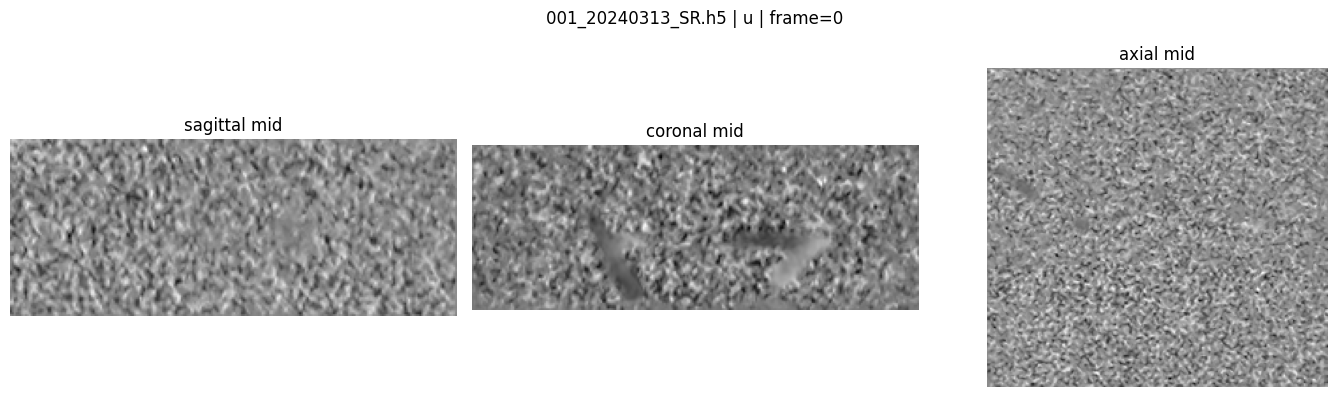

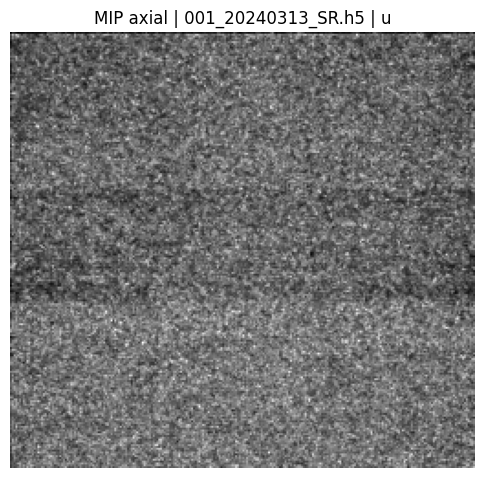

In [21]:
# Visualizacion de un caso
case_idx = 0
frame = 0
key = "u"   # prueba: u, v, w, mag_u, mask

fp = h5_files[case_idx]
with h5py.File(fp, "r") as f:
    vol = get_3d_volume(f, key=key, frame=frame)

print(Path(fp).name, key, vol.shape)
plot_mid_slices(vol, f"{Path(fp).name} | {key} | frame={frame}")
plot_mip(vol, f"MIP axial | {Path(fp).name} | {key}")


## Notas

- Si el H5 viene de `nifti_to_h5`, normalmente veras keys como `u,v,w,mag_u,mag_v,mag_w,mask,venc_*,dx,triggerTimes`.
- Para predicciones, las keys pueden cambiar segun el script de guardado.
- Si quieres comparar LR vs prediccion, carga ambos archivos y grafica mismos `frame`/slices lado a lado.


## Comparacion LowRes (H5) vs HighRes 7T (NIfTI)

Esta seccion compara un caso del `.h5` (LR) contra su contraparte NIfTI 7T (HR/ground truth).
Asume que el nombre del archivo H5 es el `case_id` (por ejemplo `001_20240313.h5`) y que existe una carpeta
`<HR_NIFTI_ROOT>/<case_id>/` con `Vx.nii.gz`, `Vy.nii.gz`, `Vz.nii.gz`.


In [25]:
import nibabel as nib
from pathlib import Path

# Ajusta estos paths a tu estructura
HR_NIFTI_ROOT = Path("data/paired_dataset/hr_7t_in_3t")
HR_KEYS = {"u": "Vx.nii.gz", "v": "Vy.nii.gz", "w": "Vz.nii.gz"}


def case_id_from_h5(path: str) -> str:
    return Path(path).stem


def load_h5_component(path: str, key: str, frame: int = 0):
    with h5py.File(path, "r") as f:
        if key not in f:
            raise KeyError(f"Key '{key}' not found in {path}")
        arr = np.asarray(f[key])
    if arr.ndim == 4:   # [T,X,Y,Z]
        frame = min(frame, arr.shape[0] - 1)
        return arr[frame], frame
    if arr.ndim == 3:
        return arr, 0
    raise ValueError(f"Unsupported H5 shape for key {key}: {arr.shape}")


def load_nifti_component(path: Path, frame: int = 0):
    if not path.exists():
        raise FileNotFoundError(path)
    img = nib.load(str(path))
    arr = np.asarray(img.dataobj)
    if arr.ndim == 4:   # expected [X,Y,Z,T]
        frame = min(frame, arr.shape[-1] - 1)
        return arr[..., frame], frame
    if arr.ndim == 3:
        return arr, 0
    raise ValueError(f"Unsupported NIfTI shape: {arr.shape}")


def summarize_pair(lr_vol: np.ndarray, hr_vol: np.ndarray, tag: str):
    print(f"{tag} LR shape={lr_vol.shape} | HR shape={hr_vol.shape}")
    print(f"{tag} LR min/max/mean/std = {lr_vol.min():.6g}, {lr_vol.max():.6g}, {lr_vol.mean():.6g}, {lr_vol.std():.6g}")
    print(f"{tag} HR min/max/mean/std = {hr_vol.min():.6g}, {hr_vol.max():.6g}, {hr_vol.mean():.6g}, {hr_vol.std():.6g}")


In [26]:
def show_pair_slices(lr_vol: np.ndarray, hr_vol: np.ndarray, title: str):
    # Use center slice of each volume independently (works even if shapes differ)
    z_lr = lr_vol.shape[2] // 2
    z_hr = hr_vol.shape[2] // 2

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(lr_vol[:, :, z_lr].T, origin="lower")
    ax[0].set_title("LowRes H5 (axial mid)")
    ax[0].axis("off")

    ax[1].imshow(hr_vol[:, :, z_hr].T, origin="lower")
    ax[1].set_title("HighRes 7T NIfTI (axial mid)")
    ax[1].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_pair_mip(lr_vol: np.ndarray, hr_vol: np.ndarray, title: str):
    mip_lr = np.max(lr_vol, axis=2)
    mip_hr = np.max(hr_vol, axis=2)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(mip_lr.T, origin="lower")
    ax[0].set_title("LowRes H5 MIP")
    ax[0].axis("off")

    ax[1].imshow(mip_hr.T, origin="lower")
    ax[1].set_title("HighRes 7T MIP")
    ax[1].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


H5 case: 001_20240313_SR.h5
HR NIfTI: data/paired_dataset/hr_7t_in_3t/001_20240313_SR/Vx.nii.gz


001_20240313_SR | u | frame req=0 (lr=0, hr=0) LR shape=(254, 238, 94) | HR shape=(127, 119, 47)
001_20240313_SR | u | frame req=0 (lr=0, hr=0) LR min/max/mean/std = -1.52675, 1.35245, 0.0279076, 0.252177
001_20240313_SR | u | frame req=0 (lr=0, hr=0) HR min/max/mean/std = 0, 4095, 1727.34, 714.704


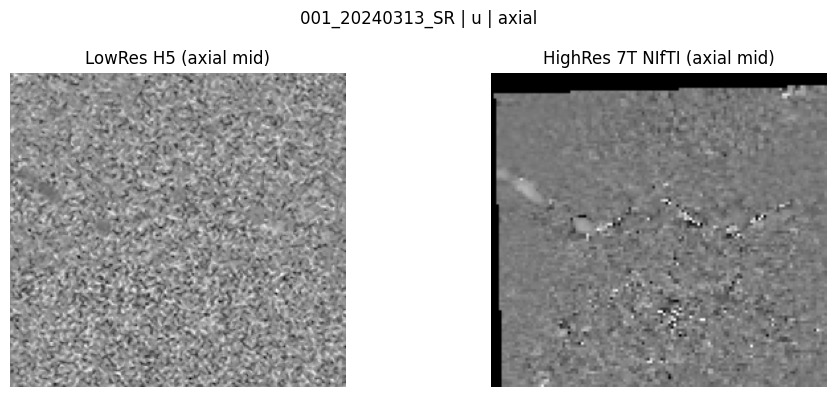

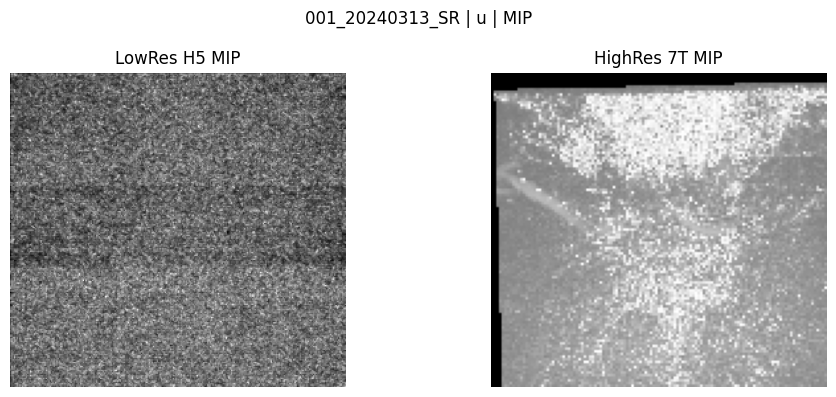

In [35]:
# Selecciona caso/componente/frame para comparar
case_idx = 0              # indice dentro de h5_files
component = "u"          # "u", "v", "w"
frame = 0

fp = h5_files[case_idx]
case_id = case_id_from_h5(fp)
hr_case_dir = HR_NIFTI_ROOT / case_id
hr_path = hr_case_dir / HR_KEYS[component]

print("H5 case:", Path(fp).name)
print("HR NIfTI:", hr_path)

lr_vol, used_frame_lr = load_h5_component(fp, component, frame=frame)
hr_vol, used_frame_hr = load_nifti_component(Path(str(hr_path).replace("_SR","")), frame=frame)

summarize_pair(lr_vol, hr_vol, f"{case_id} | {component} | frame req={frame} (lr={used_frame_lr}, hr={used_frame_hr})")
show_pair_slices(lr_vol, hr_vol, f"{case_id} | {component} | axial")
show_pair_mip(lr_vol, hr_vol, f"{case_id} | {component} | MIP")


### Nota de interpretacion

- LR y HR pueden tener distinta resolucion o rango de intensidad (normalizacion/escala), por lo que esta comparacion es de **QC visual y estadistica basica**.
- Si quieres comparar voxel-a-voxel (error map), primero hay que re-muestrear uno al grid del otro.



=== SR ===
u: shape=(9, 254, 238, 94), min=-1.5501, max=1.3524, mean=0.0259, std=0.2241, p1=-0.5622, p50=0.0243, p99=0.5863, %|x|>0.9=0.052
v: shape=(9, 254, 238, 94), min=-1.7466, max=1.4764, mean=-0.0448, std=0.2217, p1=-0.6387, p50=-0.0350, p99=0.5156, %|x|>0.9=0.085
w: shape=(9, 254, 238, 94), min=-1.8274, max=1.5068, mean=-0.0081, std=0.2252, p1=-0.6035, p50=-0.0065, p99=0.5663, %|x|>0.9=0.086
|v|: shape=(9, 254, 238, 94), min=0.0000, max=2.4272, mean=0.3303, std=0.2092, p1=0.0348, p50=0.2888, p99=0.9490

=== LR ===
u: shape=(9, 127, 119, 47), min=-0.8996, max=0.9000, mean=0.0042, std=0.3416, p1=-0.8019, p50=0.0054, p99=0.8042, %|x|>0.9=0.000
v: shape=(9, 127, 119, 47), min=-0.8996, max=0.9000, mean=0.0055, std=0.3407, p1=-0.8016, p50=0.0079, p99=0.8035, %|x|>0.9=0.000
w: shape=(9, 127, 119, 47), min=-0.9000, max=0.8996, mean=0.0030, std=0.3408, p1=-0.8029, p50=0.0043, p99=0.8032, %|x|>0.9=0.000
|v|: shape=(9, 127, 119, 47), min=0.0012, max=1.5487, mean=0.5126, std=0.2936, p1=0.0

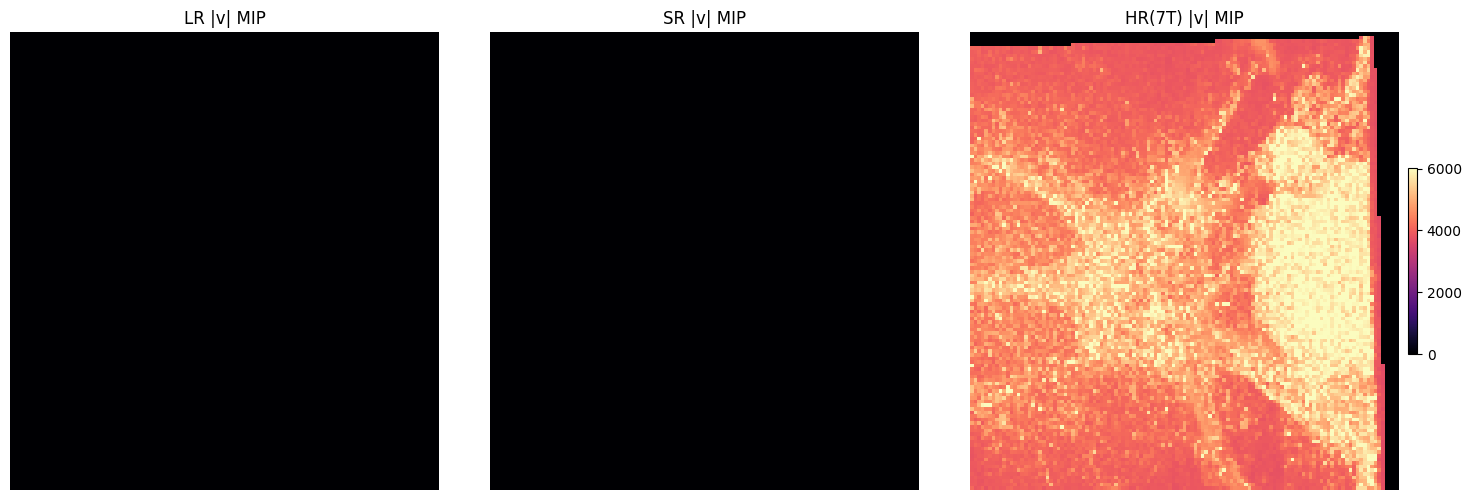

In [29]:
# QC rápido SR vs LR vs HR(7T): percentiles, outliers y MIP de |v|
import os
import h5py
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Configura estos paths
# =========================
SR_H5 = "data/predictions_h5_3t_gpu/001_20240313_SR.h5"            # tu salida SR
LR_H5 = "data/paired_dataset/h5_lr/001_20240313.h5"      # lowres de entrada en h5
HR_NIFTI_DIR = "data/paired_dataset/hr_7t_in_3t/001_20240313"  # carpeta con Vx.nii.gz, Vy.nii.gz, Vz.nii.gz
VENC = 0.90   # m/s (ajusta si aplica)
NORMALIZED = False  # True si u,v,w están normalizados por VENC; False si están en m/s

# =========================
# Helpers
# =========================
def load_h5_uvws(path):
    with h5py.File(path, "r") as f:
        u = np.array(f["u"])
        v = np.array(f["v"])
        w = np.array(f["w"])
    return u, v, w

def load_nifti_uvws(folder):
    u = nib.load(os.path.join(folder, "Vx.nii.gz")).get_fdata()
    v = nib.load(os.path.join(folder, "Vy.nii.gz")).get_fdata()
    w = nib.load(os.path.join(folder, "Vz.nii.gz")).get_fdata()
    return u, v, w

def speed(u, v, w):
    return np.sqrt(u*u + v*v + w*w)

def to_3d(vol, reduce_mode="max"):
    """Convierte volumen a 3D si viene con dimensión extra (p.ej. tiempo)."""
    vol = np.asarray(vol)
    vol = np.squeeze(vol)

    if vol.ndim == 3:
        return vol
    if vol.ndim == 4:
        # Heurística: eje temporal suele ser el menor (p.ej. 8-20 frames)
        t_axis = int(np.argmin(vol.shape))
        if reduce_mode == "max":
            return np.max(vol, axis=t_axis)
        elif reduce_mode == "mean":
            return np.mean(vol, axis=t_axis)
        elif reduce_mode == "first":
            return np.take(vol, indices=0, axis=t_axis)
        else:
            raise ValueError(f"reduce_mode no soportado: {reduce_mode}")
    raise ValueError(f"Esperaba 3D o 4D, llegó shape={vol.shape}")

def mip_axial(vol3d):
    # Asume eje Z = último eje
    return np.max(vol3d, axis=-1)

def summarize_component(x, thr):
    x = x[np.isfinite(x)]
    p1, p50, p99 = np.percentile(x, [1, 50, 99])
    return {
        "min": float(np.min(x)),
        "max": float(np.max(x)),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "p1": float(p1),
        "p50": float(p50),
        "p99": float(p99),
        "frac_out_%": float(np.mean(np.abs(x) > thr) * 100.0),
    }

def print_report(tag, u, v, w, thr):
    print(f"\n=== {tag} ===")
    for arr, name in [(u, "u"), (v, "v"), (w, "w")]:
        s = summarize_component(arr, thr)
        print(
            f"{name}: shape={arr.shape}, min={s['min']:.4f}, max={s['max']:.4f}, "
            f"mean={s['mean']:.4f}, std={s['std']:.4f}, p1={s['p1']:.4f}, "
            f"p50={s['p50']:.4f}, p99={s['p99']:.4f}, %|x|>{thr}={s['frac_out_%']:.3f}"
        )
    sp = speed(u, v, w)
    spf = sp[np.isfinite(sp)]
    p1, p50, p99 = np.percentile(spf, [1, 50, 99])
    print(
        f"|v|: shape={sp.shape}, min={spf.min():.4f}, max={spf.max():.4f}, "
        f"mean={spf.mean():.4f}, std={spf.std():.4f}, p1={p1:.4f}, p50={p50:.4f}, p99={p99:.4f}"
    )

# =========================
# Carga
# =========================
u_sr, v_sr, w_sr = load_h5_uvws(SR_H5)
u_lr, v_lr, w_lr = load_h5_uvws(LR_H5)
u_hr, v_hr, w_hr = load_nifti_uvws(HR_NIFTI_DIR)

thr = 1.0 if NORMALIZED else VENC

# Reporte numérico
print_report("SR", u_sr, v_sr, w_sr, thr)
print_report("LR", u_lr, v_lr, w_lr, thr)
print_report("HR_7T", u_hr, v_hr, w_hr, thr)

# =========================
# MIP de |v| robusto a 4D
# =========================
sp_sr_3d = to_3d(speed(u_sr, v_sr, w_sr), reduce_mode="max")
sp_lr_3d = to_3d(speed(u_lr, v_lr, w_lr), reduce_mode="max")
sp_hr_3d = to_3d(speed(u_hr, v_hr, w_hr), reduce_mode="max")

m_sr = mip_axial(sp_sr_3d)
m_lr = mip_axial(sp_lr_3d)
m_hr = mip_axial(sp_hr_3d)

vmax = np.percentile(np.concatenate([m_lr.ravel(), m_sr.ravel(), m_hr.ravel()]), 99)

plt.figure(figsize=(15, 5))
for i, (img, title) in enumerate(
    [(m_lr, "LR |v| MIP"), (m_sr, "SR |v| MIP"), (m_hr, "HR(7T) |v| MIP")], 1
):
    ax = plt.subplot(1, 3, i)
    im = ax.imshow(img, cmap="magma", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

plt.colorbar(im, fraction=0.02, pad=0.02)
plt.tight_layout()
plt.show()


HR conversion modes: u=unsigned_raw, v=unsigned_raw, w=unsigned_raw
LPS->RAS sign applied on HR U/V: True


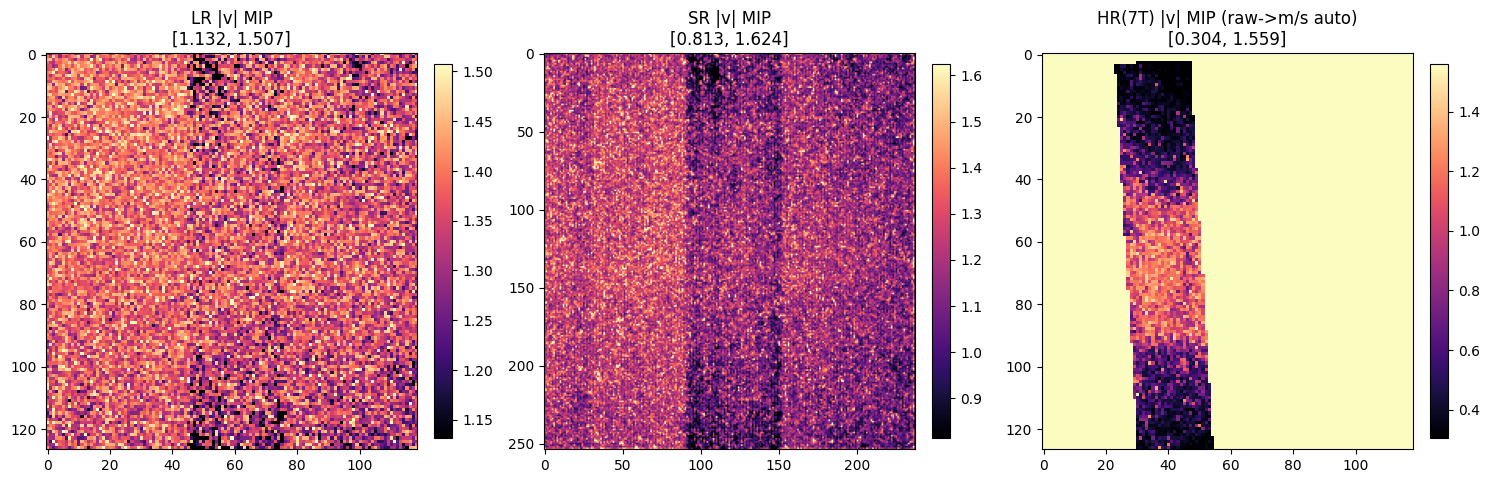

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
VENC = 0.90  # m/s

# Si tus HR vienen en convención LPS y quieres comparar contra LR/SR en RAS:
APPLY_LPS_TO_RAS_SIGN = True   # invierte signo en U y V, W se deja igual

def raw_to_ms_auto(x, venc=0.90):
    """
    Convierte RAW phase a m/s detectando automáticamente:
    - unsigned raw: ~0..4095  -> (x-2048)/2048*venc
    - signed raw:   ~-4096..4094 o ~-2048..2048 -> x/scale*venc
    Si no parece raw, devuelve x sin cambios.
    """
    x = np.asarray(x, dtype=np.float32)
    mn, mx = float(np.nanmin(x)), float(np.nanmax(x))
    max_abs = max(abs(mn), abs(mx))
    centered_ratio = abs(mx + mn) / (max_abs + 1e-6)

    is_unsigned_raw = (mn >= 0.0) and (mx > 1000.0) and (mx <= 8192.0)
    is_signed_raw = (mn < -500.0) and (mx > 500.0) and (max_abs <= 8192.0) and (centered_ratio < 0.25)

    if is_unsigned_raw:
        return (x - 2048.0) / 2048.0 * float(venc), "unsigned_raw"
    if is_signed_raw:
        scale = 4096.0 if max_abs > 3000.0 else 2048.0
        return x / scale * float(venc), f"signed_raw(scale={int(scale)})"
    return x, "already_velocity_or_unknown"

def to_3d(vol, reduce_mode="max"):
    vol = np.squeeze(np.asarray(vol))
    if vol.ndim == 3:
        return vol
    if vol.ndim == 4:
        t_axis = int(np.argmin(vol.shape))  # heurística: eje temporal suele ser el menor
        if reduce_mode == "max":
            return np.max(vol, axis=t_axis)
        if reduce_mode == "mean":
            return np.mean(vol, axis=t_axis)
        if reduce_mode == "first":
            return np.take(vol, 0, axis=t_axis)
    raise ValueError(f"Esperaba 3D/4D, llegó {vol.shape}")

def speed(u, v, w):
    return np.sqrt(u*u + v*v + w*w)

def mip_axial(vol3d):
    return np.max(vol3d, axis=-1)

# --- usa tus variables cargadas: u_sr,v_sr,w_sr,u_lr,v_lr,w_lr,u_hr,v_hr,w_hr ---

# 1) Convertir HR a m/s si está en raw (auto)
u_hr_ms, mode_u = raw_to_ms_auto(u_hr, venc=VENC)
v_hr_ms, mode_v = raw_to_ms_auto(v_hr, venc=VENC)
w_hr_ms, mode_w = raw_to_ms_auto(w_hr, venc=VENC)

# 2) Ajuste opcional de convención de ejes (LPS->RAS): U,V cambian signo
if APPLY_LPS_TO_RAS_SIGN:
    u_hr_ms = -u_hr_ms
    v_hr_ms = -v_hr_ms

print(f"HR conversion modes: u={mode_u}, v={mode_v}, w={mode_w}")
print(f"LPS->RAS sign applied on HR U/V: {APPLY_LPS_TO_RAS_SIGN}")

# 3) MIP de |v| robusto a 4D
m_lr = mip_axial(to_3d(speed(u_lr, v_lr, w_lr), reduce_mode="max"))
m_sr = mip_axial(to_3d(speed(u_sr, v_sr, w_sr), reduce_mode="max"))
m_hr = mip_axial(to_3d(speed(u_hr_ms, v_hr_ms, w_hr_ms), reduce_mode="max"))

imgs = [m_lr, m_sr, m_hr]
titles = ["LR |v| MIP", "SR |v| MIP", "HR(7T) |v| MIP (raw->m/s auto)"]

plt.figure(figsize=(15, 5))
for i, (img, title) in enumerate(zip(imgs, titles), 1):
    ax = plt.subplot(1, 3, i)
    finite = img[np.isfinite(img)]
    vmin, vmax = np.percentile(finite, [1, 99])  # escala robusta por panel
    im = ax.imshow(img, cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(f"{title}\n[{vmin:.3f}, {vmax:.3f}]")
    ax.axis("on")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
